In [1]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
import sklearn

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)


In [4]:
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

In [5]:
#load dataset
df = pd.read_csv('bike_sales.csv')
print(f'Shape: {df.shape}')
print(df.dtypes)
print(df.describe().round(2))

Shape: (1000, 18)
brand                              str
model                              str
cc                               int64
segment                            str
year                             int64
speedometer_type                   str
top_speed_kmh                    int64
mileage_kmpl                   float64
fuel_tank_liters               float64
factory_price_inr                int64
gst_rate_pct                   float64
gst_amount_inr                   int64
ex_showroom_inr                  int64
on_road_price_inr                int64
overall_score                    int64
price_increase_scenario_pct    float64
buyer_behaviour                    str
price_sensitivity                  str
dtype: object
            cc     year  top_speed_kmh  mileage_kmpl  fuel_tank_liters  \
count  1000.00  1000.00        1000.00       1000.00           1000.00   
mean    228.88  2022.61         135.35         42.84             13.41   
std     122.60     1.69          28.96      

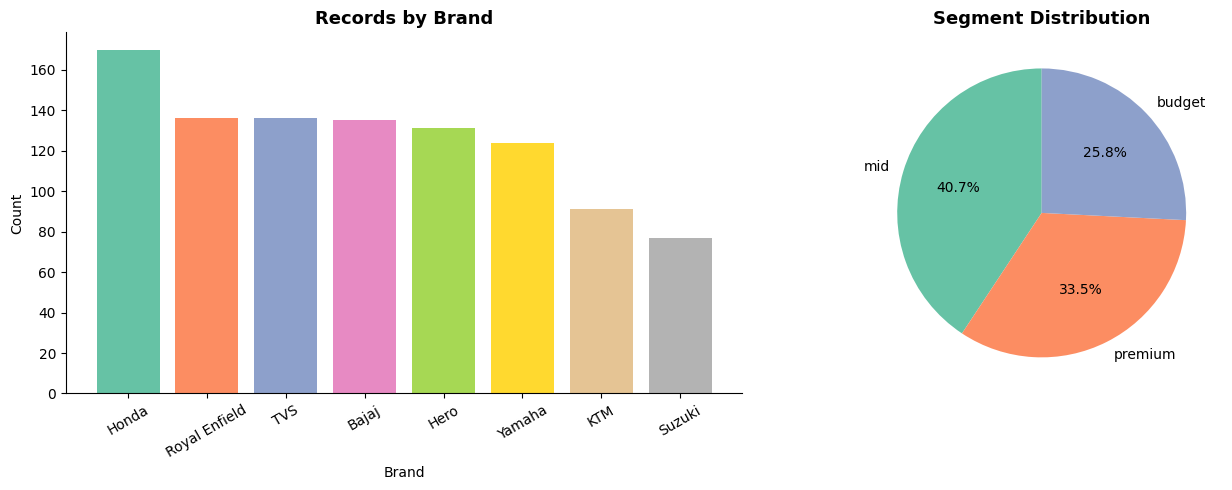

In [6]:
#EDA Brand & Segment-----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brand_counts = df['brand'].value_counts()

axes[0].bar(
    brand_counts.index,
    brand_counts.values,
    color=sns.color_palette('Set2', len(brand_counts))
)

axes[0].set_title('Records by Brand', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Brand')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

seg_counts = df['segment'].value_counts()

axes[1].pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2', 3),
    startangle=90
)

axes[1].set_title('Segment Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

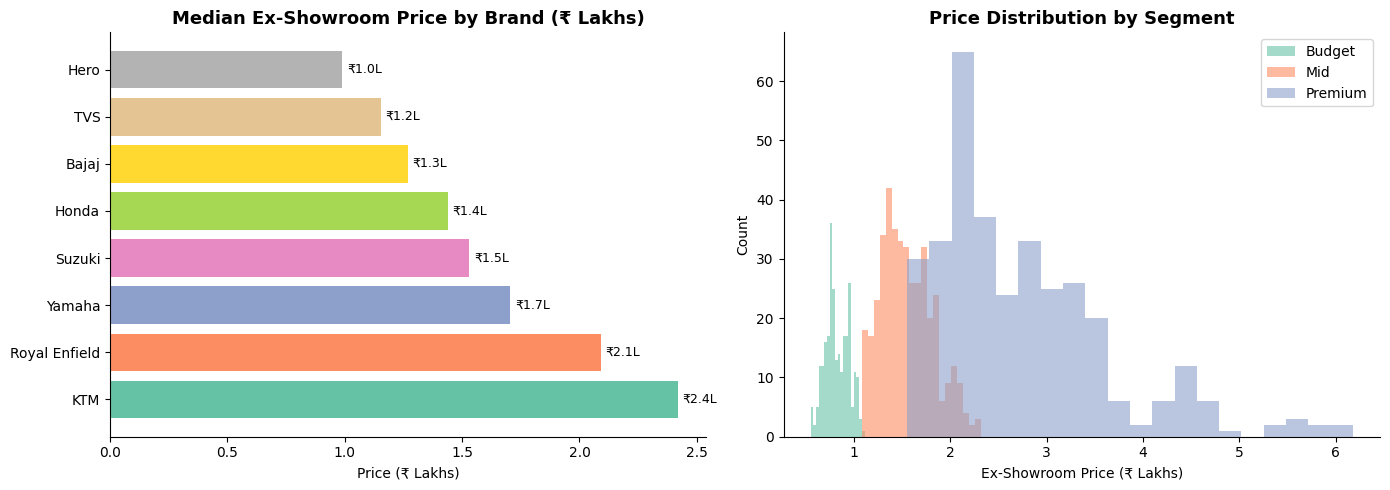

In [7]:
#EDA Price Analysis-----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

brand_price = (
    df.groupby('brand')['ex_showroom_inr']
    .median()
    .sort_values(ascending=False)
)

axes[0].barh(
    brand_price.index,
    brand_price.values / 1e5,
    color=sns.color_palette('Set2', len(brand_price))
)

axes[0].set_title(
    'Median Ex-Showroom Price by Brand (₹ Lakhs)',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('Price (₹ Lakhs)')

for i, v in enumerate(brand_price.values):
    axes[0].text(v/1e5 + 0.02, i, f'₹{v/1e5:.1f}L',
                 va='center', fontsize=9)

for seg in ['budget', 'mid', 'premium']:
    axes[1].hist(
        df[df['segment'] == seg]['ex_showroom_inr'] / 1e5,
        alpha=0.6,
        bins=20,
        label=seg.capitalize()
    )

axes[1].set_title(
    'Price Distribution by Segment',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel('Ex-Showroom Price (₹ Lakhs)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()




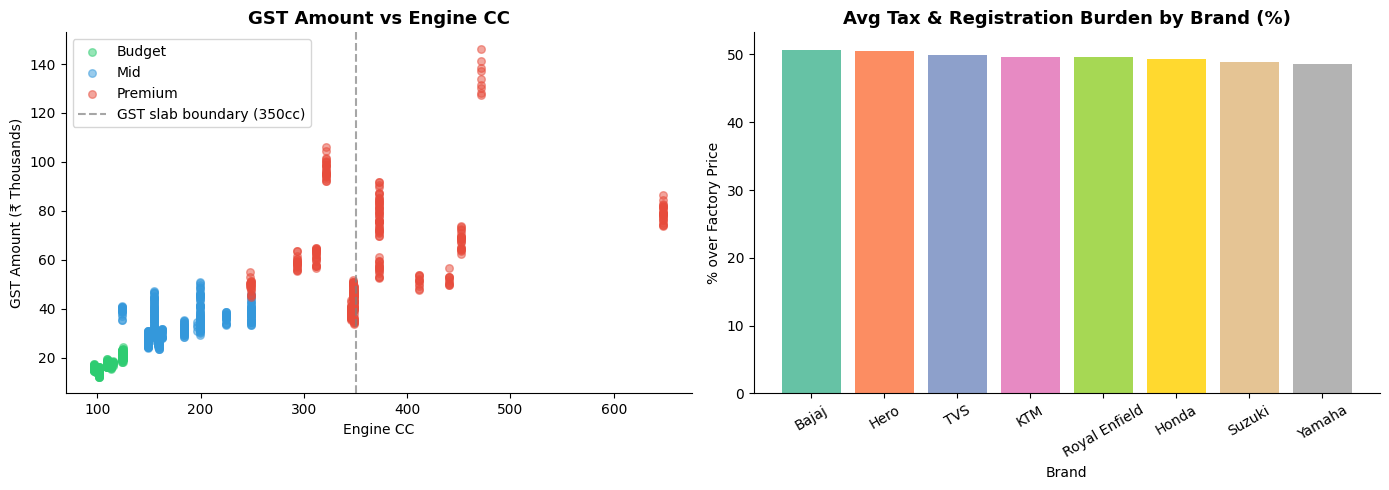

In [8]:
#EDA GST Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    'budget': '#2ecc71',
    'mid': '#3498db',
    'premium': '#e74c3c'
}

for seg, grp in df.groupby('segment'):
    axes[0].scatter(
        grp['cc'],
        grp['gst_amount_inr'] / 1000,
        alpha=0.5,
        label=seg.capitalize(),
        color=colors[seg],
        s=30
    )

axes[0].axvline(
    x=350,
    color='gray',
    linestyle='--',
    alpha=0.7,
    label='GST slab boundary (350cc)'
)

axes[0].set_title(
    'GST Amount vs Engine CC',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('Engine CC')
axes[0].set_ylabel('GST Amount (₹ Thousands)')
axes[0].legend()

df['tax_burden_pct'] = (
    (df['on_road_price_inr'] - df['factory_price_inr'])
    / df['factory_price_inr']
) * 100

brand_tax = (
    df.groupby('brand')['tax_burden_pct']
    .mean()
    .sort_values(ascending=False)
)

axes[1].bar(
    brand_tax.index,
    brand_tax.values,
    color=sns.color_palette('Set2', len(brand_tax))
)

axes[1].set_title(
    'Avg Tax & Registration Burden by Brand (%)',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel('Brand')
axes[1].set_ylabel('% over Factory Price')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


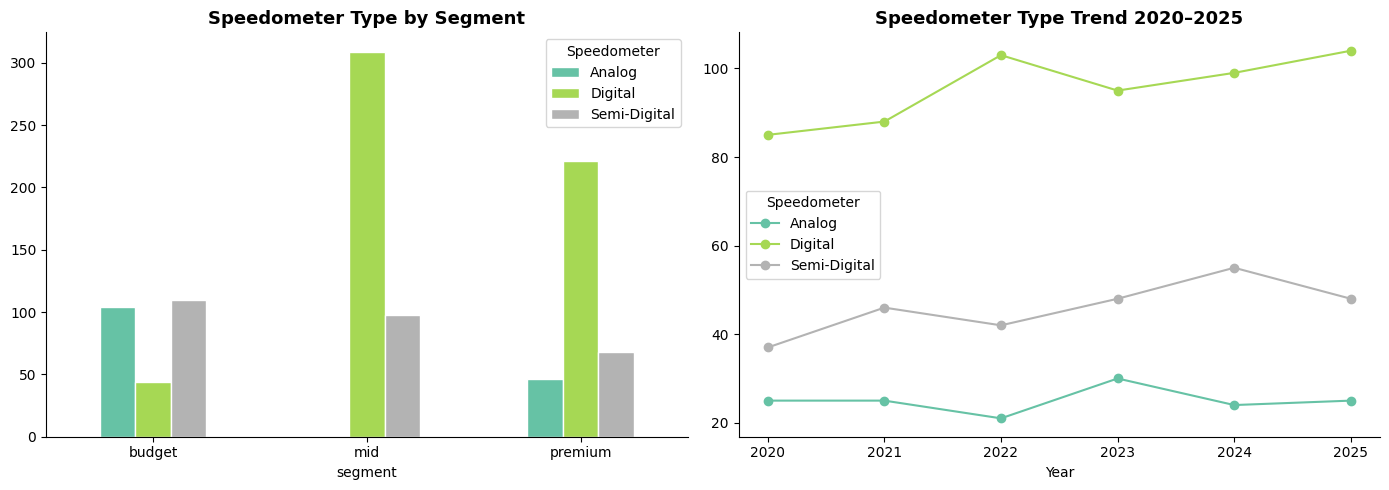

In [9]:
#EDA Speedometer Trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

speedo_seg = (
    df.groupby(['segment', 'speedometer_type'])
    .size()
    .unstack(fill_value=0)
)

speedo_seg.plot(
    kind='bar',
    ax=axes[0],
    colormap='Set2',
    edgecolor='white'
)

axes[0].set_title(
    'Speedometer Type by Segment',
    fontsize=13,
    fontweight='bold'
)

axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Speedometer')

speedo_year = (
    df.groupby(['year', 'speedometer_type'])
    .size()
    .unstack(fill_value=0)
)

speedo_year.plot(
    kind='line',
    ax=axes[1],
    marker='o',
    colormap='Set2'
)

axes[1].set_title(
    'Speedometer Type Trend 2020–2025',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel('Year')
axes[1].legend(title='Speedometer')

plt.tight_layout()
plt.show()


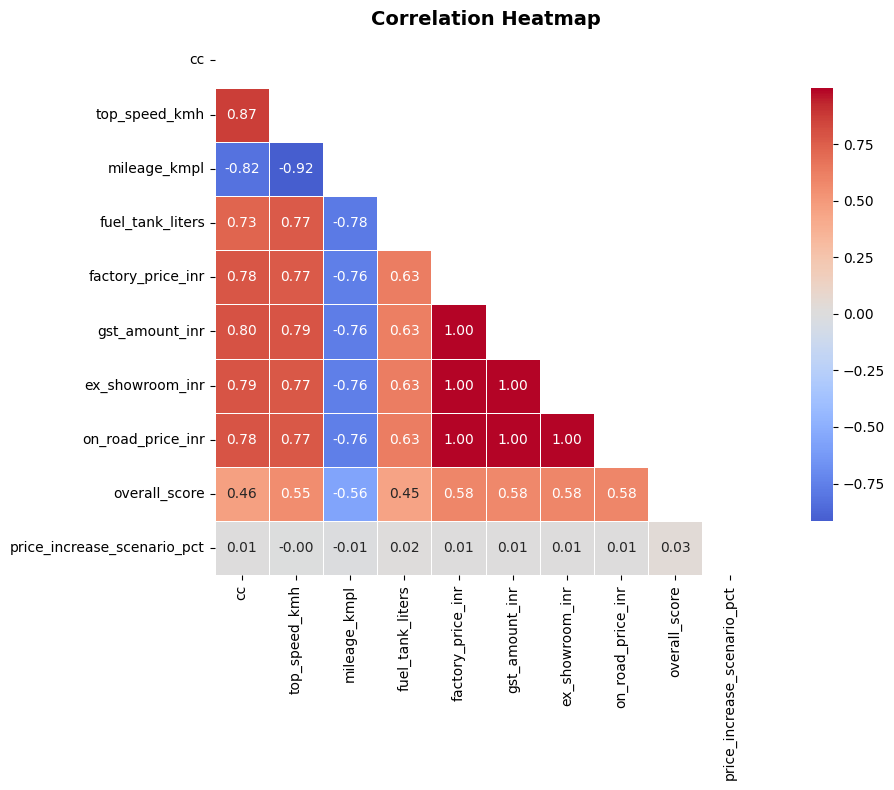

In [10]:
#EDA Correlation Heatmap
num_cols = [
    'cc',
    'top_speed_kmh',
    'mileage_kmpl',
    'fuel_tank_liters',
    'factory_price_inr',
    'gst_amount_inr',
    'ex_showroom_inr',
    'on_road_price_inr',
    'overall_score',
    'price_increase_scenario_pct'
]

plt.figure(figsize=(12, 8))

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


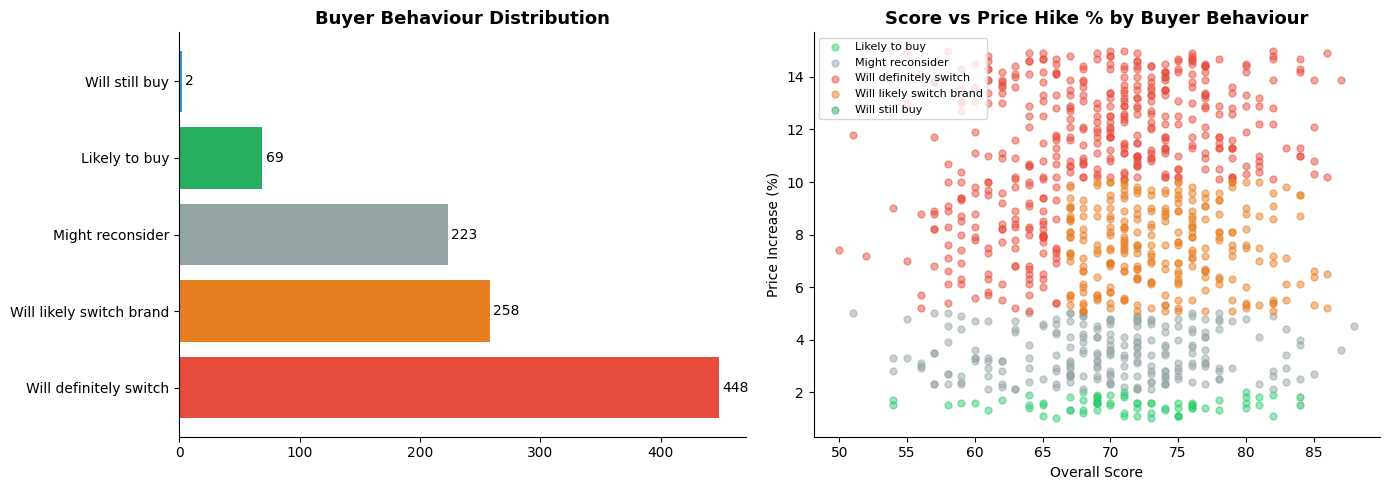

In [ ]:
# EDA: Buyer Behaviour
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

beh_counts = df['buyer_behaviour'].value_counts()

axes[0].barh(
    beh_counts.index,
    beh_counts.values,
    color=['#e74c3c', '#e67e22', '#95a5a6', '#27ae60', '#3498db']
)

axes[0].set_title(
    'Buyer Behaviour Distribution',
    fontsize=13,
    fontweight='bold'
)

for i, v in enumerate(beh_counts.values):
    axes[0].text(v + 3, i, str(v), va='center', fontsize=10)

beh_colors = {
    'Will still buy': '#27ae60',
    'Likely to buy': '#2ecc71',
    'Might reconsider': '#95a5a6',
    'Will likely switch brand': '#e67e22',
    'Will definitely switch': '#e74c3c'
}

for beh, grp in df.groupby('buyer_behaviour'):
    axes[1].scatter(
        grp['overall_score'],
        grp['price_increase_scenario_pct'],
        alpha=0.5,
        label=beh,
        color=beh_colors.get(beh, 'gray'),
        s=25
    )

axes[1].set_title(
    'Score vs Price Hike % by Buyer Behaviour',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel('Overall Score')
axes[1].set_ylabel('Price Increase (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

FEATURE ENGINEERING

In [12]:
df_ml = df.copy()

le = LabelEncoder()

for col in ['brand', 'model', 'segment', 'speedometer_type']:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])

FEATURES = [
    'cc',
    'top_speed_kmh',
    'mileage_kmpl',
    'fuel_tank_liters',
    'overall_score',
    'year',
    'gst_rate_pct',
    'brand_enc',
    'segment_enc',
    'speedometer_type_enc'
]

Linear Regression  — MAE: ₹36,304  R²: 0.7147
Random Forest      — MAE: ₹11,072  R²: 0.9785


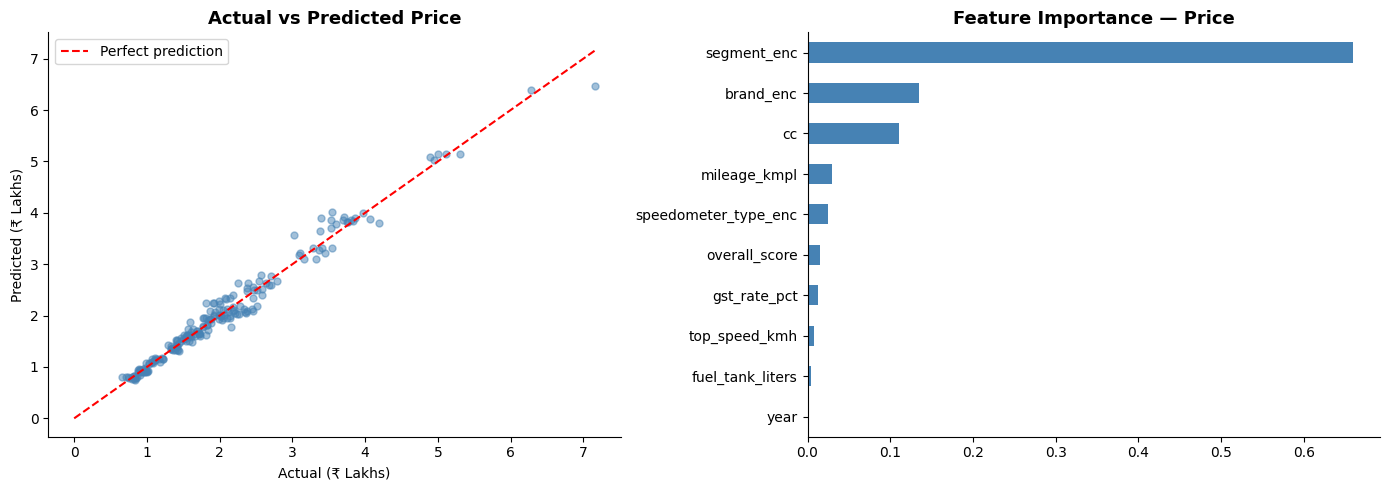

In [13]:
# Price Prediction
X = df_ml[FEATURES]
y = df_ml['on_road_price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
).fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    f'Linear Regression  — MAE: ₹{mean_absolute_error(y_test, lr_pred):,.0f}  '
    f'R²: {r2_score(y_test, lr_pred):.4f}'
)

print(
    f'Random Forest      — MAE: ₹{mean_absolute_error(y_test, rf_pred):,.0f}  '
    f'R²: {r2_score(y_test, rf_pred):.4f}'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    y_test / 1e5,
    rf_pred / 1e5,
    alpha=0.5,
    color='steelblue',
    s=25
)

mv = max(y_test.max(), rf_pred.max()) / 1e5

axes[0].plot(
    [0, mv],
    [0, mv],
    'r--',
    lw=1.5,
    label='Perfect prediction'
)

axes[0].set_title(
    'Actual vs Predicted Price',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('Actual (₹ Lakhs)')
axes[0].set_ylabel('Predicted (₹ Lakhs)')
axes[0].legend()

pd.Series(
    rf.feature_importances_,
    index=FEATURES
).sort_values().plot(
    kind='barh',
    ax=axes[1],
    color='steelblue'
)

axes[1].set_title(
    'Feature Importance — Price',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Random Forest Accuracy    : 0.9950
Gradient Boosting Accuracy: 1.0000

Classification Report:

                          precision    recall  f1-score   support

           Likely to buy       1.00      1.00      1.00        14
        Might reconsider       1.00      1.00      1.00        45
  Will definitely switch       1.00      1.00      1.00        89
Will likely switch brand       1.00      1.00      1.00        52

                accuracy                           1.00       200
               macro avg       1.00      1.00      1.00       200
            weighted avg       1.00      1.00      1.00       200



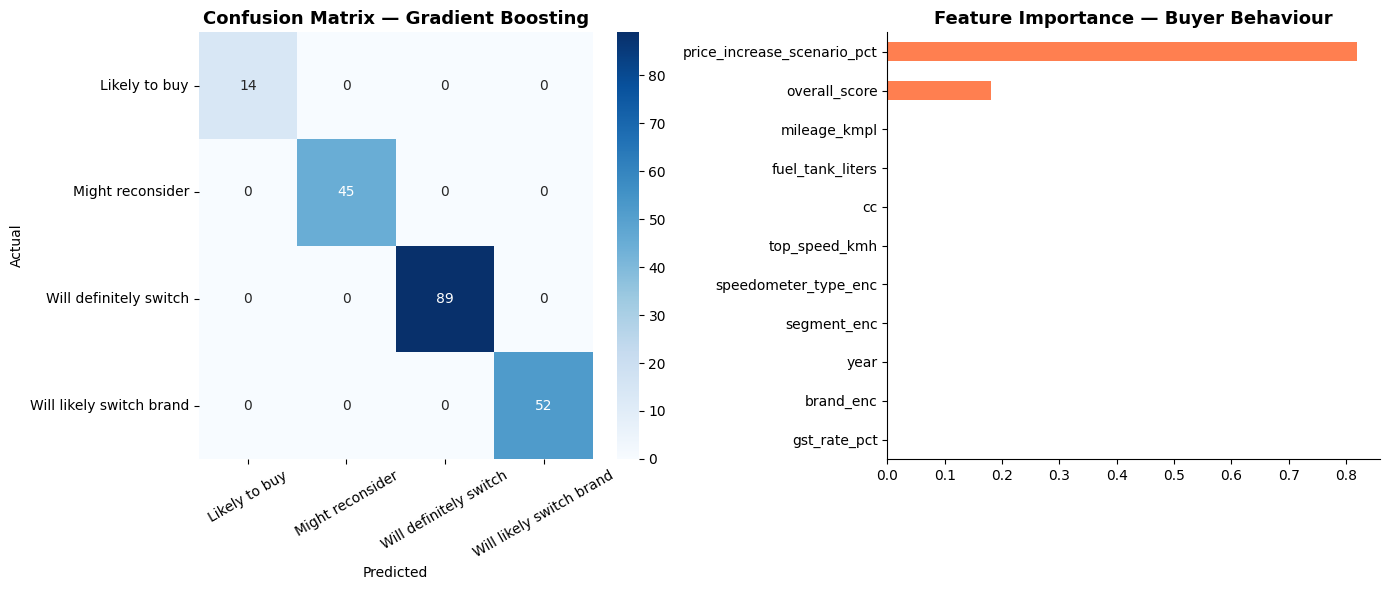


✅ Done! 


In [15]:
#Buyer Behaviour Classification
le_beh = LabelEncoder()

df_ml['behaviour_enc'] = le_beh.fit_transform(df_ml['buyer_behaviour'])

behaviour_classes = le_beh.classes_

CLF_FEATURES = FEATURES + ['price_increase_scenario_pct']

X_clf = df_ml[CLF_FEATURES]
y_clf = df_ml['behaviour_enc']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# Random Forest Classifier
rfc = RandomForestClassifier(
    n_estimators=100,
    random_state=42
).fit(X_tr, y_tr)

rfc_pred = rfc.predict(X_te)

# Gradient Boosting Classifier
gbc = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
).fit(X_tr, y_tr)

gbc_pred = gbc.predict(X_te)

# Accuracy Scores
print(f'Random Forest Accuracy    : {accuracy_score(y_te, rfc_pred):.4f}')
print(f'Gradient Boosting Accuracy: {accuracy_score(y_te, gbc_pred):.4f}')

# Safe labels handling
labels = np.unique(np.concatenate([y_te, gbc_pred]))

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_te,
        gbc_pred,
        labels=labels,
        target_names=behaviour_classes[labels]
    )
)

# ── Confusion Matrix & Feature Importance ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    confusion_matrix(y_te, gbc_pred, labels=labels),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=behaviour_classes[labels],
    yticklabels=behaviour_classes[labels],
    ax=axes[0]
)

axes[0].set_title(
    'Confusion Matrix — Gradient Boosting',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[0].tick_params(axis='x', rotation=30)

pd.Series(
    gbc.feature_importances_,
    index=CLF_FEATURES
).sort_values().plot(
    kind='barh',
    ax=axes[1],
    color='coral'
)

axes[1].set_title(
    'Feature Importance — Buyer Behaviour',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print("\n✅ Done! ")